# Subscription-Trajectory Classification — 01 · Direct Multiclass

**Programme.** We model each subscription *expiry event* into one of four trajectory
classes — `CHURN`, `CONTRACTION`, `STABLE`, `EXPANSION` — using only pre-expiry
information. `INSUFFICIENT_DATA` events are excluded (`is_modellable == 1`).

The classification work is split across notebooks that all share `clf_utils.py`
(data contract, splits, metrics):

1. **01 · Direct multiclass** *(this notebook)* — baselines, a model zoo compared
   under user-grouped CV, and a **repeated-holdout** final evaluation: the tuned
   models are re-tuned and re-evaluated on **5 independent random 15% held-out user
   splits**, with scores reported as **mean ± standard error**.
2. **02 · Two-stage** — renewal (binary) then movement, vs. the direct model.
3. **02b · Two-stage regression** — regress `vol_ratio` / post-volume, then threshold, vs. direct.
4. **03 · Deep learning** — a GRU sequence model over the daily listening panel (separate notebook).

Each modelling notebook also carries a **time-before-renewal** section (§9/§10): how
accuracy decays when the decision must be made *c* days before expiry, on older data only.

**Protocol (airtight repeated holdout).** For each of `U.RUN_SEEDS` we re-derive a
fresh **user-grouped** 15% holdout and 5 CV folds (`U.assign_run_split`), so a user's
rows are *entirely* dev or *entirely* holdout in a run and no user spans a fold.
Within each run the hyper-parameters are **re-tuned from scratch on that run's dev
users only** (user-grouped 3-fold CV), the tuned models are refit on all dev users,
and evaluated **once** on that run's untouched holdout. Nothing is carried between
runs, so there is no train/test user overlap and no cross-run leakage. The seeds are
shared across notebooks 01/02/02b, so run *r* uses the same held-out users everywhere
(paired comparisons). No `leakage_cols` ever enter `X` (asserted in `build_X`).
Primary metric: **macro-F1** (all four classes matter, and `CHURN` is rare).


In [1]:
%load_ext autoreload
%autoreload 2
import warnings; warnings.filterwarnings('ignore')
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')
import clf_utils as U
print('model classes :', U.MODEL_CLASSES)
print('base features :', len(U.BASE_FEATURES))

model classes : ['CHURN', 'CONTRACTION', 'STABLE', 'EXPANSION']
base features : 29


## 1 · Load data & assemble target

One row per `(msno, expiry_event)`. We load only the modellable rows and the
columns the experiment needs, build the feature matrix, and check the class
balance is consistent between development and held-out users.

In [2]:
df = U.load_events(feature_set='base', modellable_only=True)
X  = U.build_X(df, 'base')           # leakage-guarded feature matrix
y  = U.y_multiclass(df)              # 0..3 in U.MODEL_CLASSES order
print('rows:', f'{len(df):,}', '| features:', X.shape[1])
print('dev:', f'{U.dev_mask(df).sum():,}', '| holdout:', f'{U.holdout_mask(df).sum():,}')

bal = pd.DataFrame({
    'dev':     pd.Series(y[U.dev_mask(df)]).map(U.CODE_TO_CLASS).value_counts(normalize=True),
    'holdout': pd.Series(y[U.holdout_mask(df)]).map(U.CODE_TO_CLASS).value_counts(normalize=True),
}).reindex(U.MODEL_CLASSES).round(3)
print('\nclass balance (proportion):'); print(bal)
bal

rows: 3,784,500 | features: 29
dev: 3,215,995 | holdout: 568,505

class balance (proportion):
               dev  holdout
CHURN        0.042    0.043
CONTRACTION  0.154    0.153
STABLE       0.631    0.631
EXPANSION    0.173    0.173


,dev,holdout
CHURN,0.042,0.043
CONTRACTION,0.154,0.153
STABLE,0.631,0.631
EXPANSION,0.173,0.173


## 2 · Naive baselines

`DummyClassifier` lower bounds: always-majority (`STABLE`), and label-prior random.
Any real model must clear these on macro-F1.

In [3]:
from sklearn.dummy import DummyClassifier
base_rows = []
for strat in ['most_frequent', 'stratified', 'prior']:
    d = DummyClassifier(strategy=strat, random_state=U.RANDOM_STATE)
    d.fit(X[U.dev_mask(df)], y[U.dev_mask(df)])
    p = d.predict(X[U.holdout_mask(df)])
    s = U.score_block(y[U.holdout_mask(df)], p); s['strategy'] = strat
    base_rows.append(s)
baselines = pd.DataFrame(base_rows).set_index('strategy').round(4)
print(baselines); baselines

               accuracy  balanced_acc  macro_f1  weighted_f1
strategy                                                    
most_frequent    0.6310        0.2500    0.1934       0.4882
stratified       0.4535        0.2501    0.2501       0.4534
prior            0.6310        0.2500    0.1934       0.4882


,accuracy,balanced_acc,macro_f1,weighted_f1
strategy,,,,
most_frequent,0.6310,0.2500,0.1934,0.4882
stratified,0.4535,0.2501,0.2501,0.4534
prior,0.6310,0.2500,0.1934,0.4882


## 3 · Model zoo & user-grouped CV comparison

Six families compared under the pre-baked user-grouped folds on a label-stratified
dev subsample (fast, leakage-free because folds never split a user). Class
imbalance handled per-model (`class_weight='balanced'` / balanced sample weights /
CatBoost `auto_class_weights`). Categoricals are one-hot for the linear/RF
pipelines and native for the gradient-boosting models.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, balanced_accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

CATS = U.categorical_columns(X)
NUMS = U.numeric_columns(X)
print('categorical:', CATS)
print('numeric    :', len(NUMS))

# Fixed, GLOBAL category levels per categorical column (incl. 'NA' for missing), computed
# once on the full matrix X. A consistent category universe across every train/val/holdout
# split keeps XGBoost's categorical encoder stable — otherwise a fold whose train slice
# happens to lack 'NA' errors at predict ("Found a category not in the training set").
CAT_LEVELS = {c: sorted(X[c].astype('object').where(X[c].notna(), 'NA').astype(str).unique())
              for c in CATS}

def _string_cats(Xin):
    """Cast categorical cols to a FIXED string-coded category dtype (NaN -> 'NA').
    Fixed global levels make the encoding identical across splits, which XGBoost/CatBoost
    require (they reject float-coded categories and, for XGBoost, unseen categories at predict)."""
    Xc = Xin.copy()
    for c in CATS:
        s = Xin[c].astype('object').where(Xin[c].notna(), 'NA').astype(str)
        Xc[c] = pd.Categorical(s, categories=CAT_LEVELS[c])
    return Xc

def make_linear():
    num = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat = OneHotEncoder(handle_unknown='ignore', min_frequency=50)
    pre = ColumnTransformer([('num', num, NUMS), ('cat', cat, CATS)])
    return Pipeline([('pre', pre),
                     ('clf', LogisticRegression(max_iter=300, class_weight='balanced'))])

def make_rf():
    cat = OneHotEncoder(handle_unknown='ignore', min_frequency=50)
    pre = ColumnTransformer([('num', SimpleImputer(strategy='median'), NUMS), ('cat', cat, CATS)])
    return Pipeline([('pre', pre),
                     ('clf', RandomForestClassifier(n_estimators=200, min_samples_leaf=20,
                              class_weight='balanced_subsample', n_jobs=-1,
                              random_state=U.RANDOM_STATE))])

def make_histgb():
    return HistGradientBoostingClassifier(categorical_features='from_dtype',
            class_weight='balanced', learning_rate=0.1, max_iter=300,
            random_state=U.RANDOM_STATE)

def make_lgbm(**kw):
    params = dict(n_estimators=400, learning_rate=0.05, num_leaves=63,
                  class_weight='balanced', n_jobs=-1, random_state=U.RANDOM_STATE, verbose=-1)
    params.update(kw)
    return LGBMClassifier(**params)

class XGBWrap:
    def __init__(self, **kw): self.kw = kw
    def fit(self, Xin, yt, sample_weight=None):
        self.model = XGBClassifier(tree_method='hist', enable_categorical=True,
                        n_jobs=-1, random_state=U.RANDOM_STATE, eval_metric='mlogloss', **self.kw)
        self.model.fit(_string_cats(Xin), yt, sample_weight=sample_weight); return self
    def predict(self, Xin):
        return np.asarray(self.model.predict(_string_cats(Xin))).astype(int)

def make_xgb():
    return XGBWrap(n_estimators=400, learning_rate=0.05, max_depth=8)

class CatBoostWrap:
    def __init__(self, **kw): self.kw = kw
    def fit(self, Xin, yt):
        Xp = _string_cats(Xin)
        self.cat_idx = [Xp.columns.get_loc(c) for c in CATS]
        self.model = CatBoostClassifier(cat_features=self.cat_idx, verbose=0,
                        random_seed=U.RANDOM_STATE, auto_class_weights='Balanced', **self.kw)
        self.model.fit(Xp, yt); return self
    def predict(self, Xin):
        return self.model.predict(_string_cats(Xin)).ravel().astype(int)

def make_catboost():
    return CatBoostWrap(iterations=400, learning_rate=0.05, depth=8)

def fit_default(m, Xt, yt): m.fit(Xt, yt); return m
def fit_sw(m, Xt, yt): m.fit(Xt, yt, sample_weight=compute_sample_weight('balanced', yt)); return m

def run_cv(make, fitfn, dfs, Xs, ys, n_folds=3):
    f1s, bals, t0 = [], [], time.time()
    for k, (tr, va) in enumerate(U.cv_folds(dfs)):
        if k >= n_folds: break
        m = fitfn(make(), Xs.iloc[tr], ys[tr])
        p = np.asarray(m.predict(Xs.iloc[va])).astype(int)
        f1s.append(f1_score(ys[va], p, average='macro'))
        bals.append(balanced_accuracy_score(ys[va], p))
    return dict(macro_f1=float(np.mean(f1s)), macro_f1_std=float(np.std(f1s)),
                balanced_acc=float(np.mean(bals)), secs=round(time.time()-t0, 1))


categorical: ['payment_method_id', 'mode_pay_method', 'city', 'gender', 'registered_via']
numeric    : 24


In [5]:
# Dev subsample for the model comparison (folds remain user-disjoint)
dev = df[U.dev_mask(df)].reset_index(drop=True)
Xdev = X[U.dev_mask(df)].reset_index(drop=True)
ydev = y[U.dev_mask(df)]
sub = U.stratified_subsample(dev, ydev, 200_000)
dfs, Xs, ys = dev.iloc[sub].reset_index(drop=True), Xdev.iloc[sub].reset_index(drop=True), ydev[sub]
print('comparison subsample:', f'{len(dfs):,}')

specs = [('LogReg', make_linear, fit_default), ('RandomForest', make_rf, fit_default),
         ('HistGB', make_histgb, fit_default), ('LightGBM', make_lgbm, fit_default),
         ('XGBoost', make_xgb, fit_sw), ('CatBoost', make_catboost, fit_default)]
rows = []
for name, make, fitfn in specs:
    r = run_cv(make, fitfn, dfs, Xs, ys, n_folds=3); r['model'] = name
    rows.append(r); print(f"{name:14s} macroF1={r['macro_f1']:.4f}  balAcc={r['balanced_acc']:.4f}  ({r['secs']}s)")
cmp = pd.DataFrame(rows).set_index('model').sort_values('macro_f1', ascending=False)
cmp.round(4)

comparison subsample: 200,001
LogReg         macroF1=0.4111  balAcc=0.5353  (17.7s)
RandomForest   macroF1=0.4270  balAcc=0.5511  (64.9s)
HistGB         macroF1=0.4267  balAcc=0.5606  (8.7s)
LightGBM       macroF1=0.4386  balAcc=0.5550  (47.3s)
XGBoost        macroF1=0.4365  balAcc=0.5504  (32.4s)
CatBoost       macroF1=0.4248  balAcc=0.5585  (298.4s)


,macro_f1,macro_f1_std,balanced_acc,secs
model,,,,
LightGBM,0.4386,0.0039,0.5550,47.3
XGBoost,0.4365,0.0045,0.5504,32.4
RandomForest,0.4270,0.0026,0.5511,64.9
HistGB,0.4267,0.0034,0.5606,8.7
CatBoost,0.4248,0.0027,0.5585,298.4
LogReg,0.4111,0.0023,0.5353,17.7


## 4 · Repeated-holdout evaluation — per-run hyper-parameter search

The headline result is produced under the repeated-holdout protocol: **5 runs**, each
with a fresh random 15% user-grouped holdout, and hyper-parameters **re-tuned inside
each run on that run's dev users only**. This cell defines the per-run randomised
searches for LightGBM and XGBoost (same grids and 3-fold user-grouped CV as before).
Each search is cached to `KKBoxData/sweeps/direct_{lgbm,xgb}_run{seed}.json`, so an
interrupted overnight run resumes without repeating a finished sweep.


In [7]:
# Per-run hyper-parameter search helpers. Re-tuned on EACH run's dev split only
# (leakage-free), cached per seed for overnight resumability. Set FORCE=True to
# ignore any cached sweep and re-search from scratch.
FORCE = False
N_TRIALS = 16
lgbm_grid = dict(n_estimators=[300, 500, 800], learning_rate=[0.03, 0.05, 0.1],
                 num_leaves=[31, 63, 127, 255], min_child_samples=[20, 50, 100, 200],
                 colsample_bytree=[0.7, 0.85, 1.0], subsample=[0.7, 0.85, 1.0],
                 reg_lambda=[0.0, 1.0, 5.0])
xgb_grid = dict(n_estimators=[300, 500, 800], learning_rate=[0.03, 0.05, 0.1],
                max_depth=[4, 6, 8, 10], min_child_weight=[1, 5, 20],
                subsample=[0.7, 0.85, 1.0], colsample_bytree=[0.7, 0.85, 1.0],
                reg_lambda=[0.0, 1.0, 5.0], gamma=[0.0, 0.5, 2.0])

def make_xgb_cfg(**kw):
    base = dict(n_estimators=400, learning_rate=0.05, max_depth=8)
    return XGBWrap(**{**base, **kw})

def sweep_lgbm(dfs, Xs, ys, seed, force=FORCE):
    """Randomised LightGBM search under 3-fold user-grouped CV on this run's dev
    subsample; returns best_params (by mean macro-F1). Cached per seed."""
    name = f'direct_lgbm_run{seed}'
    if U.has_sweep(name) and not force:
        return U.load_sweep(name)['best_params']
    rng = np.random.default_rng(seed)
    trials = []
    for _ in range(N_TRIALS):
        cfg = {k: rng.choice(v).item() for k, v in lgbm_grid.items()}
        r = run_cv(lambda: make_lgbm(**dict(cfg, subsample_freq=1)), fit_default, dfs, Xs, ys, n_folds=3)
        r.update(cfg); trials.append(r)
    td = pd.DataFrame(trials).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    bp = {k: td.iloc[0][k] for k in lgbm_grid}
    for k in ('n_estimators', 'num_leaves', 'min_child_samples'): bp[k] = int(bp[k])
    bp['subsample_freq'] = 1
    U.save_sweep(name, bp, float(td.iloc[0]['macro_f1']), results=td.to_dict('records'),
                 meta={'seed': int(seed), 'n_trials': N_TRIALS, 'subsample': int(len(dfs)), 'cv_folds': 3})
    return bp

def sweep_xgb(dfs, Xs, ys, seed, force=FORCE):
    """Randomised XGBoost search under the same protocol; balanced sample weights."""
    name = f'direct_xgb_run{seed}'
    if U.has_sweep(name) and not force:
        return U.load_sweep(name)['best_params']
    rng = np.random.default_rng(seed + 1)
    trials = []
    for _ in range(N_TRIALS):
        cfg = {k: rng.choice(v).item() for k, v in xgb_grid.items()}
        r = run_cv(lambda: make_xgb_cfg(**cfg), fit_sw, dfs, Xs, ys, n_folds=3)
        r.update(cfg); trials.append(r)
    td = pd.DataFrame(trials).sort_values('macro_f1', ascending=False).reset_index(drop=True)
    bp = {k: td.iloc[0][k] for k in xgb_grid}
    for k in ('n_estimators', 'max_depth', 'min_child_weight'): bp[k] = int(bp[k])
    U.save_sweep(name, bp, float(td.iloc[0]['macro_f1']), results=td.to_dict('records'),
                 meta={'seed': int(seed), 'n_trials': N_TRIALS, 'subsample': int(len(dfs)), 'cv_folds': 3})
    return bp

print('per-run sweep helpers ready | seeds:', U.RUN_SEEDS)


per-run sweep helpers ready | seeds: [42, 43, 44, 45, 46]


## 4b · The 5-run loop

Each iteration: (1) `U.assign_run_split(df, seed)` stamps a fresh user-grouped 15%
holdout and 5 folds; (2) a label-stratified 200k dev subsample is drawn; (3) LightGBM
and XGBoost are **re-tuned on that dev subsample**; (4) both are refit on all dev
users and scored **once** on the run's untouched holdout. Per-run scores and per-class
F1 are accumulated; the first run's fitted models are retained for the diagnostic
plots below. This is the slow, overnight cell.


In [10]:
# Repeated-holdout loop: re-tune + refit + evaluate on 5 independent user-grouped splits.
run_records, perclass_records, champ_per_run = [], [], []
rep = {}
t_all = time.time()
for ri, seed in enumerate(U.RUN_SEEDS):
    t0 = time.time()
    U.assign_run_split(df, seed)                       # fresh user-grouped 15% holdout + 5 folds
    mask_dev, mask_ho = U.dev_mask(df), U.holdout_mask(df)

    # tuning subsample from THIS run's dev users only (folds remain user-disjoint)
    dev  = df[mask_dev].reset_index(drop=True)
    Xdev = X[mask_dev].reset_index(drop=True)
    ydev = y[mask_dev]
    sub  = U.stratified_subsample(dev, ydev, 200_000, random_state=seed)
    dfs_r = dev.iloc[sub].reset_index(drop=True)
    Xs_r  = Xdev.iloc[sub].reset_index(drop=True)
    ys_r  = ydev[sub]

    bp  = sweep_lgbm(dfs_r, Xs_r, ys_r, seed)          # re-tuned on this run's dev
    xbp = sweep_xgb(dfs_r, Xs_r, ys_r, seed)

    # refit tuned models on ALL dev users, evaluate once on this run's holdout
    Xtr, ytr = X[mask_dev], y[mask_dev]
    Xho, yho = X[mask_ho], y[mask_ho]
    lgbm_f = make_lgbm(**bp).fit(Xtr, ytr)
    xgb_f  = fit_sw(make_xgb_cfg(**xbp), Xtr, ytr)
    preds  = {'LightGBM': np.asarray(lgbm_f.predict(Xho)).astype(int),
              'XGBoost':  np.asarray(xgb_f.predict(Xho)).astype(int)}

    scored = {m: U.score_block(yho, pr) for m, pr in preds.items()}
    for mname, sb in scored.items():
        run_records.append({**sb, 'model': mname, 'run': ri, 'seed': int(seed),
                            'n_holdout': int(mask_ho.sum())})
        pcf = U.per_class_f1(yho, preds[mname], U.MODEL_CLASSES)
        perclass_records.append({**pcf.to_dict(), 'model': mname, 'run': ri, 'seed': int(seed)})

    champ = 'LightGBM' if scored['LightGBM']['macro_f1'] >= scored['XGBoost']['macro_f1'] else 'XGBoost'
    champ_per_run.append(champ)
    if ri == 0:                                        # keep run-0 artifacts for diagnostics
        rep = dict(seed=int(seed), best_params=bp, xgb_best_params=xbp,
                   lgbm_final=lgbm_f, xgb_final=xgb_f, yho=yho,
                   pred_lgbm=preds['LightGBM'], pred_xgb=preds['XGBoost'],
                   feat_cols=list(Xtr.columns), champion=champ)
    print(f"run {ri} seed={seed}  holdout={int(mask_ho.sum()):,}  "
          f"LGBM={scored['LightGBM']['macro_f1']:.4f}  XGB={scored['XGBoost']['macro_f1']:.4f}  "
          f"champ={champ}  ({time.time()-t0:.0f}s)")
print(f"\nAll {len(U.RUN_SEEDS)} runs complete in {(time.time()-t_all)/60:.1f} min")


run 0 seed=42  holdout=571,207  LGBM=0.4349  XGB=0.4363  champ=XGBoost  (1262s)
run 1 seed=43  holdout=568,823  LGBM=0.4389  XGB=0.4406  champ=XGBoost  (3589s)
run 2 seed=44  holdout=567,778  LGBM=0.4398  XGB=0.4416  champ=XGBoost  (3429s)
run 3 seed=45  holdout=567,786  LGBM=0.4384  XGB=0.4392  champ=XGBoost  (4127s)
run 4 seed=46  holdout=566,081  LGBM=0.4377  XGB=0.4386  champ=XGBoost  (3351s)

All 5 runs complete in 262.6 min


## 5 · Aggregate results — mean ± standard error over the 5 runs

Headline reporting. Per-run holdout scores are aggregated to **mean ± SE**
(SE = std / √5) for each model family, and per-class F1 is summarised for the
reported champion (the family with the higher mean holdout macro-F1). Row-normalised
and raw-count confusion matrices are shown for the representative (run-0) champion fit.


Per-run holdout macro-F1:
model  LightGBM  XGBoost
run                     
0        0.4349   0.4363
1        0.4389   0.4406
2        0.4398   0.4416
3        0.4384   0.4392
4        0.4377   0.4386

Champion counts per run: {'XGBoost': 5}

Mean ± SE over 5 runs:
                 accuracy     balanced_acc         macro_f1      weighted_f1
model                                                                       
LightGBM  0.4913 ± 0.0008  0.5728 ± 0.0005  0.4379 ± 0.0008  0.5186 ± 0.0008
XGBoost   0.4934 ± 0.0009  0.5709 ± 0.0003  0.4393 ± 0.0009  0.5205 ± 0.0008

Reported champion (max mean macro-F1): XGBoost

Per-class F1 (champion, mean ± SE):
  CHURN        0.4166 ± 0.0024
  CONTRACTION  0.3194 ± 0.0003
  STABLE       0.6054 ± 0.0010
  EXPANSION    0.4156 ± 0.0003


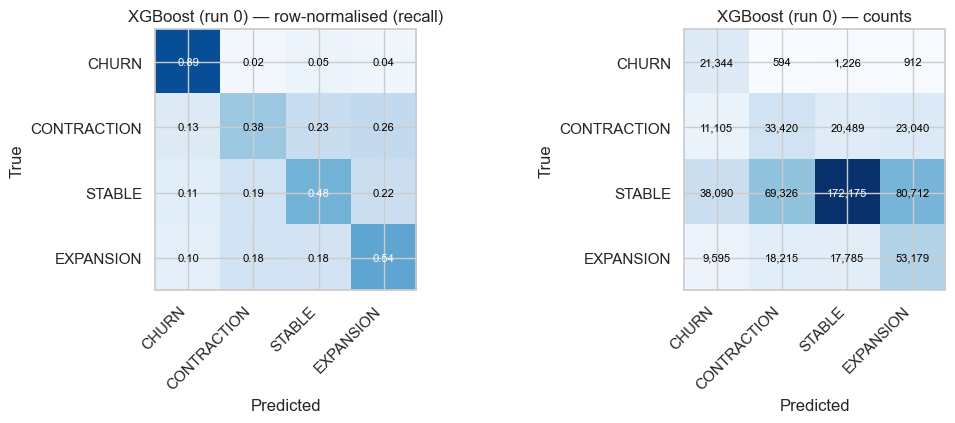

,accuracy,balanced_acc,macro_f1,weighted_f1
model,,,,
LightGBM,0.4913 ± 0.0008,0.5728 ± 0.0005,0.4379 ± 0.0008,0.5186 ± 0.0008
XGBoost,0.4934 ± 0.0009,0.5709 ± 0.0003,0.4393 ± 0.0009,0.5205 ± 0.0008


In [11]:
runs_df = pd.DataFrame(run_records)
metrics = ['accuracy', 'balanced_acc', 'macro_f1', 'weighted_f1']
summary = U.agg_mean_se(runs_df, 'model', metrics).set_index('model')

# Reported champion family = higher MEAN holdout macro-F1 across the 5 runs
final_name = summary['macro_f1_mean'].idxmax()
best_params, xgb_best_params = rep['best_params'], rep['xgb_best_params']

print('Per-run holdout macro-F1:')
print(runs_df.pivot(index='run', columns='model', values='macro_f1').round(4))
print(f"\nChampion counts per run: {pd.Series(champ_per_run).value_counts().to_dict()}")
print(f'\nMean \u00b1 SE over {len(U.RUN_SEEDS)} runs:')
show = pd.DataFrame({
    m: summary.apply(lambda r, m=m: f"{r[f'{m}_mean']:.4f} \u00b1 {r[f'{m}_se']:.4f}", axis=1)
    for m in metrics})
print(show)
print(f"\nReported champion (max mean macro-F1): {final_name}")

# Per-class F1 mean +/- SE for the champion family
pc_df = pd.DataFrame(perclass_records)
pc_champ = pc_df[pc_df['model'] == final_name].copy()
pc_summary = U.agg_mean_se(pc_champ, 'model', U.MODEL_CLASSES)
print('\nPer-class F1 (champion, mean \u00b1 SE):')
for c in U.MODEL_CLASSES:
    print(f"  {c:12s} {pc_summary[f'{c}_mean'].iloc[0]:.4f} \u00b1 {pc_summary[f'{c}_se'].iloc[0]:.4f}")

# Persist raw per-run tables + aggregated summaries
runs_df.to_csv(U.DATA / 'clf_direct_holdout_runs.csv', index=False)
summary.reset_index().to_csv(U.DATA / 'clf_direct_holdout_summary.csv', index=False)
pc_df.to_csv(U.DATA / 'clf_direct_perclass_runs.csv', index=False)
pc_summary.to_csv(U.DATA / 'clf_direct_perclass_summary.csv', index=False)
# backward-compatible single-row champion metrics (now mean-over-runs with SE)
champ_row = summary.loc[[final_name]].reset_index()
champ_row.insert(0, 'model_label', f'{final_name}_tuned_meanSE')
champ_row.to_csv(U.DATA / 'clf_direct_holdout_metrics.csv', index=False)

# Representative-run (run 0) champion confusion matrices
rep_pred = rep['pred_lgbm'] if final_name == 'LightGBM' else rep['pred_xgb']
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
U.plot_confusion(rep['yho'], rep_pred, U.MODEL_CLASSES, ax=ax[0],
                 title=f'{final_name}: recall', normalize='true')
U.plot_confusion(rep['yho'], rep_pred, U.MODEL_CLASSES, ax=ax[1],
                 title=f'{final_name}: counts', normalize=None)
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_direct_confusion.png', dpi=130); plt.show()
show


## 6 · Feature importance — robustness across the five holdout runs

Rather than reading one run's ranking, we extract XGBoost split-gain importance from **all
five** repeated-holdout fits and ask whether the run-0 picture is representative. Each run's
raw gain is normalised to a within-run *share* (so independently fitted models are comparable),
then aggregated to a mean share ± standard error across runs, with per-run ranks and top-5/top-10
appearance counts.

Fitted models are reused from memory/cache where possible; a run is only refit from its **cached**
per-run hyper-parameters (`KKBoxData/sweeps/direct_xgb_run{seed}.json`) when its fitted model is
unavailable — the 16-trial searches are never re-run here. Gain is specific to this XGBoost direct
multiclass model and reflects contribution to tree splits, not the direction of an effect.


In [ ]:

# Reuse fitted models from memory/cache; only refit a run from its CACHED per-run
# hyper-parameters when its fitted model is unavailable (sweeps are never re-run here).
FORCE_IMPORTANCE = False
RAW_IMP_CSV = U.DATA / 'clf_direct_importance_5runs_raw.csv'

# Canonical, full feature list (identical across runs; only the split changes).
FEATURES = list(rep['feat_cols']) if ('rep' in globals() and rep.get('feat_cols')) else list(X.columns)


def _xgb_gain_series(model, features):
    """feature -> gain, reindexed to the full feature list with zeros for unused features."""
    booster = model.model.get_booster()                       # XGBWrap -> XGBClassifier -> Booster
    gain = booster.get_score(importance_type='gain')          # used features only
    return pd.Series(gain, dtype='float64').reindex(features).fillna(0.0)


def _collect_xgb_run_models():
    """Return [(run, seed, fitted_xgb_model)] for all five runs.
    Priority: in-memory list -> run-0 `rep` fit -> refit from CACHED per-run params."""
    if 'xgb_run_models' in globals() and len(xgb_run_models) == len(U.RUN_SEEDS):
        print('Using five XGBoost models already held in memory (no refit).')
        return xgb_run_models
    models = []
    for ri, seed in enumerate(U.RUN_SEEDS):
        # run 0 was retained by the repeated-holdout loop for diagnostics
        if ri == 0 and 'rep' in globals() and rep.get('xgb_final') is not None \
                and int(rep.get('seed', -1)) == int(seed):
            models.append((ri, int(seed), rep['xgb_final']))
            print(f"run {ri} seed={seed}: reused run-0 fit from memory (rep['xgb_final']).")
            continue
        name = f'direct_xgb_run{seed}'
        payload = U.load_sweep(name)
        if payload is None:
            raise RuntimeError(
                f"Cached hyper-parameters '{name}.json' not found — run the 5-run loop "
                f"(section 4b) first so the per-run XGBoost sweeps exist.")
        xbp = payload['best_params']
        U.assign_run_split(df, seed)                          # restore this run's user-grouped split
        mask_dev = U.dev_mask(df)
        Xtr, ytr = X[mask_dev], y[mask_dev]
        t0 = time.time()
        m = fit_sw(make_xgb_cfg(**xbp), Xtr, ytr)             # refit on ALL dev users, cached params
        models.append((ri, int(seed), m))
        print(f"run {ri} seed={seed}: refit XGB on {int(mask_dev.sum()):,} dev rows "
              f"from cached params ({time.time()-t0:.0f}s).")
    globals()['xgb_run_models'] = models
    U.assign_run_split(df, U.RUN_SEEDS[0])                    # leave df on the run-0 split (matches rep)
    return models


if RAW_IMP_CSV.exists() and not FORCE_IMPORTANCE:
    imp_long = pd.read_csv(RAW_IMP_CSV)
    print(f"Loaded cached per-run importance from {RAW_IMP_CSV.name} "
          f"({imp_long['run'].nunique()} runs, {imp_long['feature'].nunique()} features).")
else:
    recs = []
    for ri, seed, model in _collect_xgb_run_models():
        g = _xgb_gain_series(model, FEATURES)
        share = g / g.sum()                            
        for feat in FEATURES:
            recs.append(dict(run=ri, seed=int(seed), feature=feat,
                             gain=float(g[feat]), gain_share=float(share[feat])))
    imp_long = pd.DataFrame(recs)
    imp_long.to_csv(RAW_IMP_CSV, index=False)
    print(f"Built per-run importance for {imp_long['run'].nunique()} runs; "
          f"saved raw long table -> {RAW_IMP_CSV}")

# Each run's gain shares must sum to ~1.
_sums = imp_long.groupby('run')['gain_share'].sum()
assert np.allclose(_sums.values, 1.0, atol=1e-6), f"gain_share must sum to 1 per run: {_sums.to_dict()}"
print('gain_share sums per run:', {int(k): round(float(v), 6) for k, v in _sums.items()})
imp_long.head()


run 0 seed=42: refit XGB on 3,213,293 dev rows from cached params (319s).
run 1 seed=43: refit XGB on 3,215,677 dev rows from cached params (332s).
run 2 seed=44: refit XGB on 3,216,722 dev rows from cached params (319s).
run 3 seed=45: refit XGB on 3,216,714 dev rows from cached params (643s).
run 4 seed=46: refit XGB on 3,218,419 dev rows from cached params (600s).
Built per-run importance for 5 runs; saved raw long table -> /Users/jesperphillips/Masters Studies/Dissertation/KKBoxData/clf_direct_importance_5runs_raw.csv
gain_share sums per run: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}


,run,seed,feature,gain,gain_share
0,0,42,pre_total_secs,12.513744,0.004300
1,0,42,pre_n_days,34.315216,0.011793
2,0,42,pre_rate,8.573630,0.002946
3,0,42,pre_list_price,12.485005,0.004291
4,0,42,pre_amount_paid,25.437384,0.008742


In [ ]:

n_runs = int(imp_long['run'].nunique())

# Per-run rank of each feature (1 = highest gain share in that run).
imp_long = imp_long.copy()
imp_long['rank'] = imp_long.groupby('run')['gain_share'].rank(ascending=False, method='min')


def _agg(group):
    shares = group['gain_share'].to_numpy()
    ranks = group['rank'].to_numpy()
    sd = float(np.std(shares, ddof=1))
    return pd.Series({
        'mean_gain_share': float(np.mean(shares)),
        'sd_gain_share': sd,
        'se_gain_share': sd / np.sqrt(n_runs),
        'median_gain_share': float(np.median(shares)),
        'mean_rank': float(np.mean(ranks)),
        'top5_count': int(np.sum(ranks <= 5)),
        'top10_count': int(np.sum(ranks <= 10)),
    })


imp_agg = (imp_long.groupby('feature')[['gain_share', 'rank']]
           .apply(_agg)
           .sort_values('mean_gain_share', ascending=False))
print(f"Aggregated across {n_runs} runs; {len(imp_agg)} features.")
imp_agg.head(20).round(4)


Aggregated across 5 runs; 29 features.


,mean_gain_share,sd_gain_share,se_gain_share,median_gain_share,mean_rank,top5_count,top10_count
feature,,,,,,,
is_auto_renew,0.7462,0.0729,0.0326,0.7320,1.0,5.0,5.0
is_cancel,0.0818,0.0169,0.0075,0.0832,2.0,5.0,5.0
recency_days,0.0180,0.0050,0.0022,0.0170,3.6,5.0,5.0
n_prior_autorenew,0.0158,0.0092,0.0041,0.0200,7.0,4.0,4.0
payment_method_id,0.0157,0.0051,0.0023,0.0152,4.4,5.0,5.0
pre_n_days,0.0114,0.0031,0.0014,0.0115,6.4,1.0,5.0
cancel_rate,0.0112,0.0035,0.0016,0.0113,6.8,0.0,5.0
pre_amount_paid,0.0094,0.0024,0.0011,0.0087,8.0,0.0,5.0
payment_plan_days,0.0083,0.0021,0.0009,0.0078,10.0,0.0,3.0


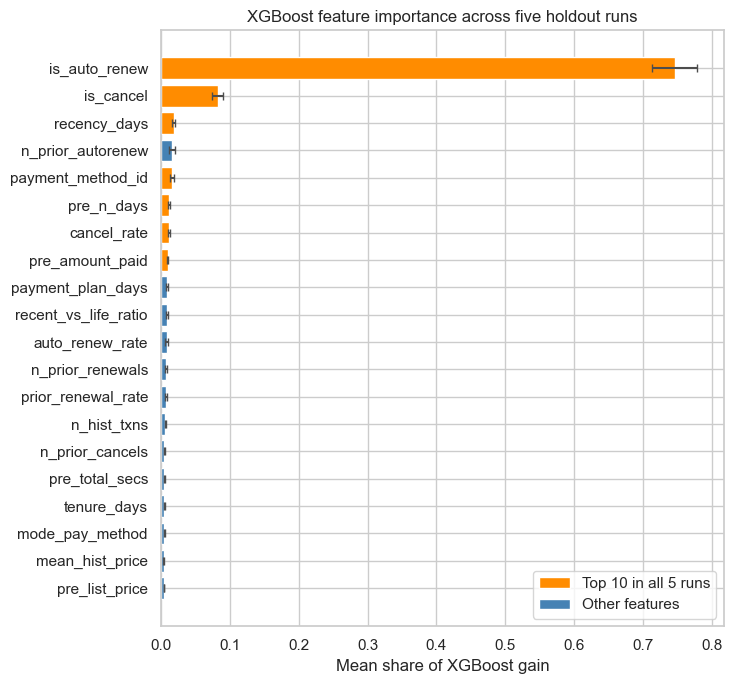

Top 10 in all five runs: ['cancel_rate', 'is_auto_renew', 'is_cancel', 'payment_method_id', 'pre_amount_paid', 'pre_n_days', 'recency_days']


,feature,mean_gain_share,se_gain_share,mean_rank,top5_count,top10_count
0,is_auto_renew,0.7462,0.0326,1.0,5.0,5.0
1,is_cancel,0.0818,0.0075,2.0,5.0,5.0
2,recency_days,0.0180,0.0022,3.6,5.0,5.0
3,n_prior_autorenew,0.0158,0.0041,7.0,4.0,4.0
4,payment_method_id,0.0157,0.0023,4.4,5.0,5.0
5,pre_n_days,0.0114,0.0014,6.4,1.0,5.0
6,cancel_rate,0.0112,0.0016,6.8,0.0,5.0
7,pre_amount_paid,0.0094,0.0011,8.0,0.0,5.0
8,payment_plan_days,0.0083,0.0009,10.0,0.0,3.0
9,recent_vs_life_ratio,0.0080,0.0012,10.0,0.0,3.0


In [ ]:

from matplotlib.patches import Patch

# Features appearing in the top 10 in all five repeated holdout runs.
robust_features = set(imp_agg.index[imp_agg['top10_count'] == 5])

top20 = imp_agg.head(20)
order = top20.iloc[::-1]                                   # largest share at the top of the bar chart

# Highlight features that appeared in the top 10 in all five runs.
bar_colors = [
    'darkorange' if feature in robust_features else 'steelblue'
    for feature in order.index
]

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.barh(
    order.index,
    order['mean_gain_share'],
    xerr=order['se_gain_share'],
    color=bar_colors,
    ecolor='0.3',
    capsize=3
)

ax.set_xlabel('Mean share of XGBoost gain')
ax.set_title('XGBoost feature importance across five holdout runs')

ax.legend(
    handles=[
        Patch(facecolor='darkorange', label='Top 10 in all 5 runs'),
        Patch(facecolor='steelblue', label='Other features')
    ],
    loc='lower right',
    frameon=True
)

plt.tight_layout()

fig_path = U.PLOTS / 'clf_direct_importance_5runs.png'
plt.savefig(fig_path, dpi=130, bbox_inches='tight')
plt.show()

print('Top 10 in all five runs:', sorted(robust_features))

# Compact robustness table (full aggregate saved; top 20 displayed).
robust_tbl = imp_agg.reset_index()[[
    'feature',
    'mean_gain_share',
    'se_gain_share',
    'mean_rank',
    'top5_count',
    'top10_count'
]]

csv_path = U.DATA / 'clf_direct_feature_importance_5runs.csv'
robust_tbl.to_csv(csv_path, index=False)

robust_tbl.head(20).round(4)


In [ ]:

per_run_rank1 = imp_long.loc[imp_long['rank'] == 1].set_index('run')['feature']
top1_feature = imp_agg.index[0]
IAR, IC = 'is_auto_renew', 'is_cancel'

iar_is_top1 = (top1_feature == IAR)
iar_rank1_runs = int((per_run_rank1 == IAR).sum())
ic_top5 = int(imp_agg.loc[IC, 'top5_count']) if IC in imp_agg.index else 0
all_top10 = imp_agg.index[imp_agg['top10_count'] == n_runs].tolist()

# Stability of the run-0 ranking vs the across-run mean ranking.
run0_top10 = imp_long[imp_long['run'] == 0].nlargest(10, 'gain_share')['feature'].tolist()
mean_top10 = imp_agg.head(10).index.tolist()
overlap = len(set(run0_top10) & set(mean_top10))

print('DOMINANT-FEATURE ROBUSTNESS CHECK  (5 XGBoost holdout runs)')
print('-' * 60)
print(f"Top feature by mean gain share : {top1_feature!r}")
print(f"Is is_auto_renew ranked #1 (mean gain share)? {'YES' if iar_is_top1 else 'NO'}")
print(f"Runs where is_auto_renew is ranked #1 : {iar_rank1_runs}/{n_runs}")
print(f"Runs where is_cancel is in the top 5  : {ic_top5}/{n_runs}")
print(f"Features in the top 10 in ALL {n_runs} runs ({len(all_top10)}): {all_top10}")
print()
print(f"Run-0 top-10 vs across-run mean top-10 overlap: {overlap}/10")
print(f"  run-0 top-10 : {run0_top10}")
print(f"  mean  top-10 : {mean_top10}")
stable = iar_is_top1 and iar_rank1_runs == n_runs and overlap >= 8
print()
print("Conclusion: the broad conclusions from the old run-0 plot are "
      + ("STABLE across runs — run-0 is representative."
         if stable else
         "only PARTIALLY stable across runs — interpret run-0 with care."))


DOMINANT-FEATURE ROBUSTNESS CHECK  (5 XGBoost holdout runs)
------------------------------------------------------------
Top feature by mean gain share : 'is_auto_renew'
Is is_auto_renew ranked #1 (mean gain share)? YES
Runs where is_auto_renew is ranked #1 : 5/5
Runs where is_cancel is in the top 5  : 5/5
Features in the top 10 in ALL 5 runs (7): ['is_auto_renew', 'is_cancel', 'recency_days', 'payment_method_id', 'pre_n_days', 'cancel_rate', 'pre_amount_paid']

Run-0 top-10 vs across-run mean top-10 overlap: 8/10
  run-0 top-10 : ['is_auto_renew', 'is_cancel', 'n_prior_autorenew', 'payment_method_id', 'recency_days', 'auto_renew_rate', 'pre_n_days', 'cancel_rate', 'pre_amount_paid', 'n_prior_cancels']
  mean  top-10 : ['is_auto_renew', 'is_cancel', 'recency_days', 'n_prior_autorenew', 'payment_method_id', 'pre_n_days', 'cancel_rate', 'pre_amount_paid', 'payment_plan_days', 'recent_vs_life_ratio']

Conclusion: the broad conclusions from the old run-0 plot are STABLE across runs — run-0

**Interpretation — read with caution.**

- Gain importance is **specific to the XGBoost direct multiclass model**; it is a property of this
  estimator, not of the data in general.
- It measures how strongly a feature contributes to tree splits, **not the direction** of any
  effect (a high-gain feature can push predictions either way).
- It must **not** be read causally — high gain does not imply that changing the feature would
  change churn/movement outcomes.
- It does **not** directly explain the tuned **deep-learning ensemble**, which is the reported
  headline model; these importances characterise the gradient-boosted baseline only.


### 6a · Direction of the dominant features (relationship with the response)

Gain importance ranks features by *how much* they help the trees split, but says
nothing about *which way* they push a prediction. The row-normalised crosstabs
below make the direction explicit — the class distribution conditioned on each
value of the two dominant flags.

In [4]:
# --- 6a · Direction: how the two dominant flags relate to the response -----------
# Descriptive (whole-dataset). Row-normalised crosstab = P(class | flag value).
lab   = pd.Series(pd.Series(y).map(U.CODE_TO_CLASS).values, name='class')
prior = lab.value_counts(normalize=True).reindex(U.MODEL_CLASSES).round(3)
print('overall class prior:')
print(prior.to_string(), '\n')

for feat in ['is_auto_renew', 'is_cancel']:
    if feat not in X.columns:
        print(f'[skip] {feat} not in X'); continue
    v    = pd.to_numeric(X[feat].reset_index(drop=True), errors='coerce')
    rate = pd.crosstab(v, lab, normalize='index').reindex(columns=U.MODEL_CLASSES).round(3)
    n    = pd.crosstab(v, lab).sum(axis=1)
    rate.insert(0, 'n_rows', n.reindex(rate.index).astype(int).values)
    print(f'{feat}  —  P(class | {feat})   [rows = flag value]')
    print(rate.to_string())
    print()


overall class prior:
class
CHURN          0.042
CONTRACTION    0.154
STABLE         0.631
EXPANSION      0.173 

is_auto_renew  —  P(class | is_auto_renew)   [rows = flag value]
class           n_rows  CHURN  CONTRACTION  STABLE  EXPANSION
is_auto_renew                                                
0               671574  0.178        0.135   0.565      0.122
1              3112926  0.013        0.158   0.645      0.184

is_cancel  —  P(class | is_cancel)   [rows = flag value]
class       n_rows  CHURN  CONTRACTION  STABLE  EXPANSION
is_cancel                                                
0          3707947  0.040        0.150   0.636      0.174
1            76553  0.162        0.331   0.389      0.118



### 6b · How much does a single feature explain? (one-feature model)

A sanity check on the dominance of `is_auto_renew`: fit the champion family
(LightGBM, balanced) on that flag **alone** across the five user-grouped holdout
runs and compare with the full-feature champion already scored on disk. This
quantifies how much of the headline macro-F1 one flag recovers by itself.

In [6]:
# --- 6b · One-feature model: is_auto_renew alone, across the five holdout runs ----
from sklearn.metrics import f1_score

SINGLE_FEAT = 'is_auto_renew'
runs_ref = pd.read_csv(U.DATA / 'clf_direct_holdout_runs.csv')
mcol = 'model' if 'model' in runs_ref.columns else runs_ref.columns[0]
full_name = runs_ref.groupby(mcol)['macro_f1'].mean().idxmax()      # champion by mean macro-F1
full_by_seed = runs_ref[runs_ref[mcol] == full_name].set_index('seed')['macro_f1']

sf_rows = []
for ri, seed in enumerate(U.RUN_SEEDS):
    U.assign_run_split(df, seed)
    md, mh = U.dev_mask(df), U.holdout_mask(df)
    Xtr = pd.to_numeric(X[md][SINGLE_FEAT], errors='coerce').fillna(-1).to_frame()
    Xho = pd.to_numeric(X[mh][SINGLE_FEAT], errors='coerce').fillna(-1).to_frame()
    m = make_lgbm(n_estimators=100).fit(Xtr, y[md])                 # class_weight='balanced' baked in
    p = np.asarray(m.predict(Xho)).astype(int)
    sf_rows.append(dict(run=ri, seed=int(seed),
                        single_macro_f1=f1_score(y[mh], p, average='macro'),
                        full_macro_f1=float(full_by_seed.get(seed, np.nan))))

sf = pd.DataFrame(sf_rows)
sf['recovered_frac'] = (sf['single_macro_f1'] / sf['full_macro_f1']).round(3)

def _mse(s): return f'{s.mean():.4f} ± {s.std(ddof=1) / np.sqrt(len(s)):.4f}'
print(f'single feature      : {SINGLE_FEAT}')
print(f'full-feature model  : {full_name}\n')
print(sf.round(4).to_string(index=False))
print(f'\nsingle-feature macro-F1 : {_mse(sf["single_macro_f1"])}  (mean ± SE over {len(sf)} runs)')
print(f'full-feature  macro-F1 : {_mse(sf["full_macro_f1"])}')
print(f'fraction recovered      : {sf["recovered_frac"].mean():.1%} of the champion on one feature')

sf.to_csv(U.DATA / 'clf_direct_single_feature_5runs.csv', index=False)
_ = U.assign_run_split(df, U.RUN_SEEDS[0])   # restore run-0 split for downstream cells


single feature      : is_auto_renew
full-feature model  : XGBoost

 run  seed  single_macro_f1  full_macro_f1  recovered_frac
   0    42           0.1473         0.4363           0.338
   1    43           0.1481         0.4406           0.336
   2    44           0.1482         0.4416           0.336
   3    45           0.1479         0.4392           0.337
   4    46           0.1474         0.4386           0.336

single-feature macro-F1 : 0.1478 ± 0.0002  (mean ± SE over 5 runs)
full-feature  macro-F1 : 0.4393 ± 0.0009
fraction recovered      : 33.7% of the champion on one feature


## 7 · Walk-forward validation

Expanding window by expiry month: train on `month_idx <= t`, test on `t+1`
(dev users only), using the **champion** family with its run-0 tuned params. Pinned to
the run-0 split for reproducibility. Checks temporal stability.


train<= 0  test 1: macroF1=0.4422  balAcc=0.5230
train<= 1  test 2: macroF1=0.4419  balAcc=0.5475
train<= 2  test 3: macroF1=0.4528  balAcc=0.5634
train<= 3  test 4: macroF1=0.4309  balAcc=0.5102
train<= 4  test 5: macroF1=0.4454  balAcc=0.5688


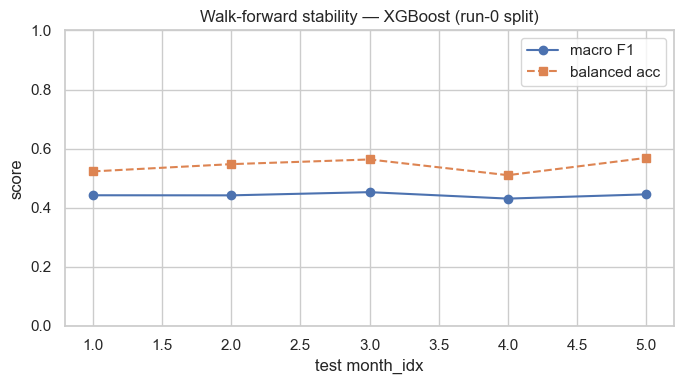

,accuracy,balanced_acc,macro_f1,weighted_f1,train_le,test_month,test_n
0,0.5099,0.5230,0.4422,0.5334,0,1,529419
1,0.5155,0.5475,0.4419,0.5411,1,2,543482
2,0.5249,0.5634,0.4528,0.5506,2,3,545571
3,0.5172,0.5102,0.4309,0.5462,3,4,551732
4,0.5076,0.5688,0.4454,0.5329,4,5,565623


In [13]:
# Walk-forward is a temporal-stability diagnostic; pin it to the run-0 split so
# dev membership is fixed and reproducible, using the reported champion + its run-0 params.
U.assign_run_split(df, U.RUN_SEEDS[0])

def make_champion():
    """Return (fresh_model, fit_fn) for the champion family (run-0 tuned params)."""
    if final_name == 'LightGBM':
        return make_lgbm(**best_params), fit_default
    return make_xgb_cfg(**xgb_best_params), fit_sw

wf = []
for tr, tst, t in U.walk_forward_splits(df):
    m, ff = make_champion(); m = ff(m, X.iloc[tr], y[tr])
    s = U.score_block(y[tst], np.asarray(m.predict(X.iloc[tst])).astype(int))
    s['train_le'] = t; s['test_month'] = t + 1; s['test_n'] = len(tst)
    wf.append(s); print(f"train<= {t}  test {t+1}: macroF1={s['macro_f1']:.4f}  balAcc={s['balanced_acc']:.4f}")
wf_df = pd.DataFrame(wf)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(wf_df['test_month'], wf_df['macro_f1'], 'o-', label='macro-F1')
ax.plot(wf_df['test_month'], wf_df['balanced_acc'], 's--', label='balanced acc')
ax.set_xlabel('test month'); ax.set_ylabel('score'); ax.set_ylim(0, 1)
ax.legend(); ax.set_title(f'Walk-forward stability — {final_name}')
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_direct_walkforward.png', dpi=130); plt.show()
wf_df.round(4)


## 8 · Persist artifacts & summary

In [14]:
import joblib
final_model = rep['lgbm_final'] if final_name == 'LightGBM' else rep['xgb_final']
joblib.dump(final_model, U.DATA / 'clf_direct_champion.joblib')       # representative run-0 champion
joblib.dump(rep['lgbm_final'], U.DATA / 'clf_direct_lightgbm.joblib')
baselines.to_csv(U.DATA / 'clf_direct_baselines.csv')
cmp.to_csv(U.DATA / 'clf_direct_model_comparison.csv')
wf_df.round(4).to_csv(U.DATA / 'clf_direct_walkforward.csv', index=False)
# (repeated-holdout summaries were written in section 5:
#  clf_direct_holdout_runs.csv, clf_direct_holdout_summary.csv,
#  clf_direct_perclass_runs.csv, clf_direct_perclass_summary.csv, clf_direct_holdout_metrics.csv)
print('Saved direct-multiclass artifacts to', U.DATA)
print('Per-seed sweeps cached in', U.SWEEP_DIR, '->',
      [p.name for p in sorted(U.SWEEP_DIR.glob('direct_*_run*.json'))])
mf = summary.loc[final_name]
print(f"Reported champion: {final_name} | holdout macro-F1 = "
      f"{mf['macro_f1_mean']:.4f} \u00b1 {mf['macro_f1_se']:.4f} (mean \u00b1 SE, {len(U.RUN_SEEDS)} runs)")


Saved direct-multiclass artifacts to /Users/jesperphillips/Masters Studies/Dissertation/KKBoxData
Per-seed sweeps cached in /Users/jesperphillips/Masters Studies/Dissertation/KKBoxData/sweeps -> ['direct_lgbm_run42.json', 'direct_lgbm_run43.json', 'direct_lgbm_run44.json', 'direct_lgbm_run45.json', 'direct_lgbm_run46.json', 'direct_xgb_run42.json', 'direct_xgb_run43.json', 'direct_xgb_run44.json', 'direct_xgb_run45.json', 'direct_xgb_run46.json']
Reported champion: XGBoost | holdout macro-F1 = 0.4393 ± 0.0009 (mean ± SE, 5 runs)


### 9 · Time cutoff before renewal — **true cutoff** (genuine rebuild, drop-in)

This section is a true cutoff: **every** base feature is recomputed at the decision
date `E−c` directly from raw transactions and listening logs, *as if all data in `[E−c, E)` never
existed* — not column masking, but a from-raw rebuild (`truecut_precompute.py` →
`truecut_base_c{c}.parquet`). The transaction event fields become the most recent transaction on or
before `E−c`; history counts/rates, `recency_days`, `tenure_days` and `obs_secs_per_active_day` are
all re-aggregated strictly before `E−c`; the listening window ends at `E−c`. At `c = 0` the decision is at `E`, so that row provides the at-expiry diagnostic baseline for this cutoff analysis. It is separate from the five-run headline estimate.


full data (up to E)      (n_feat=29)  macroF1=0.4380
cutoff E-7d (true)       (n_feat=29)  macroF1=0.4221
cutoff E-14d (true)      (n_feat=29)  macroF1=0.4066
cutoff E-30d (true)      (n_feat=29)  macroF1=0.3769
cutoff E-60d (true)      (n_feat=29)  macroF1=0.3593


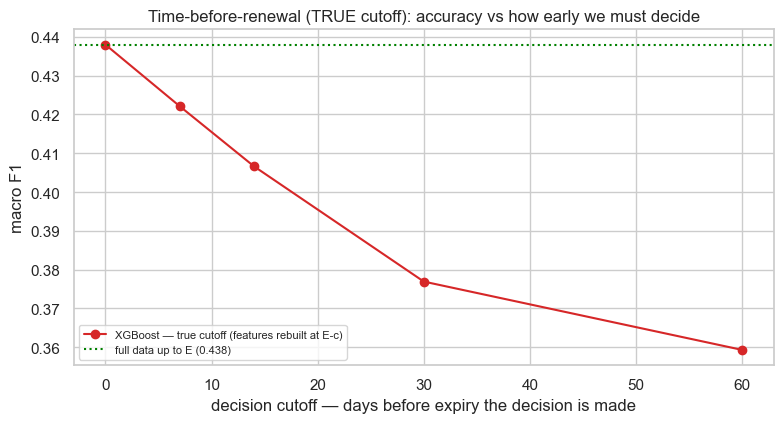

,setting,cutoff_days,n_features,macro_f1,macro_f1_std,balanced_acc
0,full data (up to E),0,29,0.4380,0.0006,0.5706
1,cutoff E-7d (true),7,29,0.4221,0.0002,0.5489
2,cutoff E-14d (true),14,29,0.4066,0.0002,0.5294
3,cutoff E-30d (true),30,29,0.3769,0.0006,0.4891
4,cutoff E-60d (true),60,29,0.3593,0.0007,0.4705


In [ ]:
import gc
# Every base feature is REBUILT at the decision date E-c from raw
# transactions + listening logs (truecut_precompute.py -> truecut_base_c{c}.parquet), i.e. "decide c
# days early as if all data in [E-c, E) never existed": event-txn fields = most recent txn <= E-c;
# history aggregates / recency / tenure / obs baseline all re-aggregated strictly before E-c; the
# listening window ends at E-c. This is NOT column masking. c=0 == engineered base (decision at E) ==
# §9's c=0 at-expiry diagnostic baseline. c=0 at-expiry diagnostic baseline. Same champion XGBoost run-0 params, same run-0 dev users, 3-fold user-grouped CV.
xgb_best_params = U.load_sweep(f'direct_xgb_run{U.RUN_SEEDS[0]}')['best_params']  # run-0 champion
CUTOFFS = [0, 7, 14, 30, 60]

rows_h = []
for c in CUTOFFS:
    dfc = pd.read_parquet(U.DATA / f'truecut_base_c{c}.parquet')   # features rebuilt at E-c
    U.assign_run_split(dfc, U.RUN_SEEDS[0])                        # same held-out users every cutoff
    Xc = U.build_X(dfc, 'base')
    dev = U.dev_mask(dfc)
    dfc_s = dfc[dev].reset_index(drop=True)
    Xc_s  = Xc[dev].reset_index(drop=True)
    yc_s  = U.y_multiclass(dfc_s)
    r = run_cv(lambda: make_xgb_cfg(**xgb_best_params), fit_sw, dfc_s, Xc_s, yc_s, n_folds=3)
    r['setting'] = 'full data (up to E)' if c == 0 else f'cutoff E-{c}d (true)'
    r['cutoff_days'] = c; r['n_features'] = Xc_s.shape[1]
    rows_h.append(r)
    print(f"{r['setting']:24s} (n_feat={Xc_s.shape[1]:2d})  macroF1={r['macro_f1']:.4f}")
    del dfc, Xc, dfc_s, Xc_s; gc.collect()

# Same table schema as §9 (clf_direct_horizon_decay.csv) -> a true drop-in.
horizon_df_true = pd.DataFrame(rows_h)[['setting', 'cutoff_days', 'n_features', 'macro_f1', 'macro_f1_std', 'balanced_acc']]
horizon_df_true.to_csv(U.DATA / 'clf_direct_horizon_decay_truecut.csv', index=False)

full_f1 = horizon_df_true.loc[horizon_df_true['cutoff_days'] == 0, 'macro_f1'].iloc[0]
fig, ax = plt.subplots(figsize=(8, 4.4))
ax.plot(horizon_df_true['cutoff_days'], horizon_df_true['macro_f1'], 'o-', color='tab:red',
        label='XGBoost')
ax.axhline(full_f1, ls=':', c='green', label=f'full data — at expiry ({full_f1:.3f})')
ax.set_xlabel('days before expiry the decision is made')
ax.set_ylabel('macro-F1'); ax.set_title('Time before renewal: accuracy vs how early the decision is made')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(U.PLOTS / 'clf_direct_horizon_decay_truecut.png', dpi=130); plt.show()
horizon_df_true.round(4)
